In [46]:
from stpy.continuous_processes.nystrom_fea import NystromFeatures
from stpy.kernels import KernelFunction
from stpy.helpers.helper import interval_torch
from doexpy.env.bandits import Bandits
from doexpy.functionals.doe_static_functionals import DesignA
from doexpy.convex_solvers.frank_wolfe import FrankWolfe
from doexpy.feedback.feedback_base import EmptyFeedback
from doexpy.solvers.dp import DP
from doexpy.policies.summary_policies.density_policy import DensityPolicy
from doexpy.mdpexplore import MdpExplore
import torch 
import matplotlib.pyplot as plt

In [47]:
# list of kernels
kernels = [KernelFunction(kernel_name="squared_exponential", gamma=0.1), 
           KernelFunction(kernel_name="squared_exponential", gamma=0.5)]
# names of the kernels
names =["RBF $\gamma = 0.01$", "RBF $\gamma = 0.1$", "RBF $\gamma = 0.5$"]

In [48]:
# define the discretized inveral [-1,1]
x = interval_torch(128,d = 1)*2

In [49]:
# We calculate finite dimensional embeddings for the intervals for easier calculation
# We use Nystrom features with thresholdon explained variance
embeddings = []
for k in kernels:
    Nystrom = NystromFeatures(k, m = None, approx = 'svd-explained')
    Nystrom.fit_gp(x, None, explained_variance = 0.999)
    embeddings.append(Nystrom.embed)

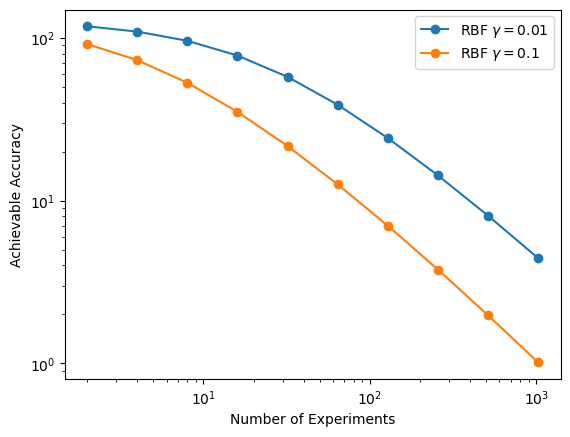

In [52]:
# define the budget of the experiment 
Ts = torch.logspace(1,10,10,base=2)
sigma = 0.05
for name, emb in zip(names,embeddings):
    values = []
    
    for T in Ts: 
        phi = emb(x)
        
        # define the environment
        env = Bandits(
            action_space=phi
        )
        
        # define the problem
        design = DesignA(
            env=env,
            lambd=1.,
            dim = 1,
            V = phi.T@phi/(sigma**2))
        
        # define the convex solver
        convex_solver = FrankWolfe(env,
                                   objective=design,
                                   num_components=10*phi.size()[1],
                                   solver=DP,
                                   step="line-search",
                                   SummarizedPolicyType=DensityPolicy,
                                   accuracy=1e-5)
        
        # define the feedback class
        feedback = EmptyFeedback(env, design)
               
        # Bandit environment 
        env = Bandits(action_space=phi)
        
        me = MdpExplore(
            env=env,
            objective=design,
            convex_solver=convex_solver,
            verbosity=0,
            feedback=feedback,
            general_policy='markovian')
        
        val, opt_val = me.run(
            episodes=int(T))
        
        values.append(-sigma**2*opt_val/T)
    plt.loglog(Ts, values,'o-', label = name)
#plt.loglog(Ts,1/Ts,'k--')
plt.xlabel("Number of Experiments")
plt.ylabel("Achievable Accuracy")
plt.legend()
